In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/Users/somesh-19583/Desktop/Customer conversion/Source data/train_data.csv")
df

,year,month,day,order,country,session_id,page1_main_category,page2_clothing_model,colour,location,model_photography,price,price_2,page
0,2008,6,22,21,29,15648,3,C20,13,1,2,48,1,2
1,2008,5,19,6,29,10018,2,B26,13,3,1,57,1,2
2,2008,7,15,2,29,19388,3,C13,9,5,1,48,1,1
3,2008,5,2,2,29,7181,2,B11,2,4,1,43,2,1
4,2008,6,9,16,29,13493,2,B31,9,5,1,57,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132374,2008,7,4,3,29,17622,4,P19,2,1,1,48,1,2
132375,2008,6,19,9,29,15165,3,C26,14,3,1,28,2,2
132376,2008,7,15,4,29,19359,1,A4,3,2,2,38,2,1
132377,2008,7,28,16,29,21454,3,C50,9,5,2,20,2,3


In [4]:
df=df.drop(columns=['year','session_id'])

In [7]:
from sklearn.preprocessing import StandardScaler

# Select relevant numerical columns
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Standardize the numerical features
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[numerical_features]), columns=numerical_features)

df_scaled


,month,day,order,country,page1_main_category,colour,location,model_photography,price,price_2,page
0,0.314174,0.848597,0.831323,0.286643,0.523645,1.597940,-1.319159,1.686940,0.335888,-0.977227,0.292634
1,-0.438805,0.508811,-0.283182,0.286643,-0.349717,1.597940,-0.152333,-0.592789,1.053629,-0.977227,0.292634
2,1.067153,0.055762,-0.580383,0.286643,0.523645,0.654173,1.014493,-0.592789,0.335888,-0.977227,-0.723941
3,-0.438805,-1.416646,-0.580383,0.286643,-0.349717,-0.997418,0.431080,-0.592789,-0.062857,1.023304,-0.723941
4,0.314174,-0.623811,0.459822,0.286643,-0.349717,0.654173,1.014493,-0.592789,1.053629,-0.977227,0.292634
...,...,...,...,...,...,...,...,...,...,...,...
132374,1.067153,-1.190122,-0.506083,0.286643,1.397008,-0.997418,-1.319159,-0.592789,0.335888,-0.977227,0.292634
132375,0.314174,0.508811,-0.060281,0.286643,0.523645,1.833881,-0.152333,-0.592789,-1.259092,1.023304,0.292634
132376,1.067153,0.055762,-0.431783,0.286643,-1.223079,-0.761476,-0.735746,1.686940,-0.461602,1.023304,-0.723941
132377,1.067153,1.528171,0.459822,0.286643,0.523645,0.654173,1.014493,1.686940,-1.897084,1.023304,1.309209


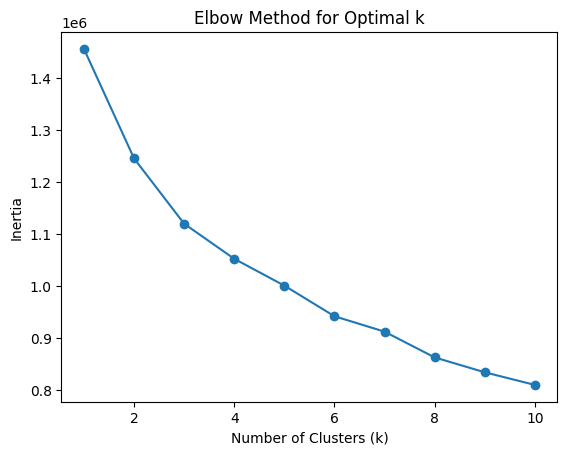

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Determine the optimal number of clusters using the Elbow Method
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

Silhouette Score: 0.1525
Davies-Bouldin Index: 2.0661
WCSS (Inertia): 1120120.34


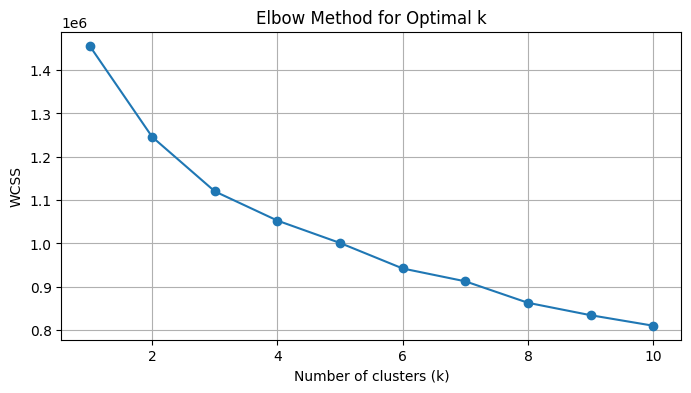

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt

# -----------------------------
# Apply KMeans clustering
# -----------------------------
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df["Cluster"] = kmeans.fit_predict(df_scaled)

# -----------------------------
# Evaluation Metrics
# -----------------------------

# 1. Silhouette Score (higher is better; range: -1 to 1)
sil_score = silhouette_score(df_scaled, df["Cluster"])
print(f"Silhouette Score: {sil_score:.4f}")

# 2. Davies-Bouldin Index (lower is better)
db_index = davies_bouldin_score(df_scaled, df["Cluster"])
print(f"Davies-Bouldin Index: {db_index:.4f}")

# 3. WCSS (Within-Cluster Sum of Squares)
wcss = kmeans.inertia_
print(f"WCSS (Inertia): {wcss:.2f}")

# -----------------------------
# Optional: Plotting Elbow Curve (for choosing optimal k)
# -----------------------------
wcss_values = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df_scaled)
    wcss_values.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss_values, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()


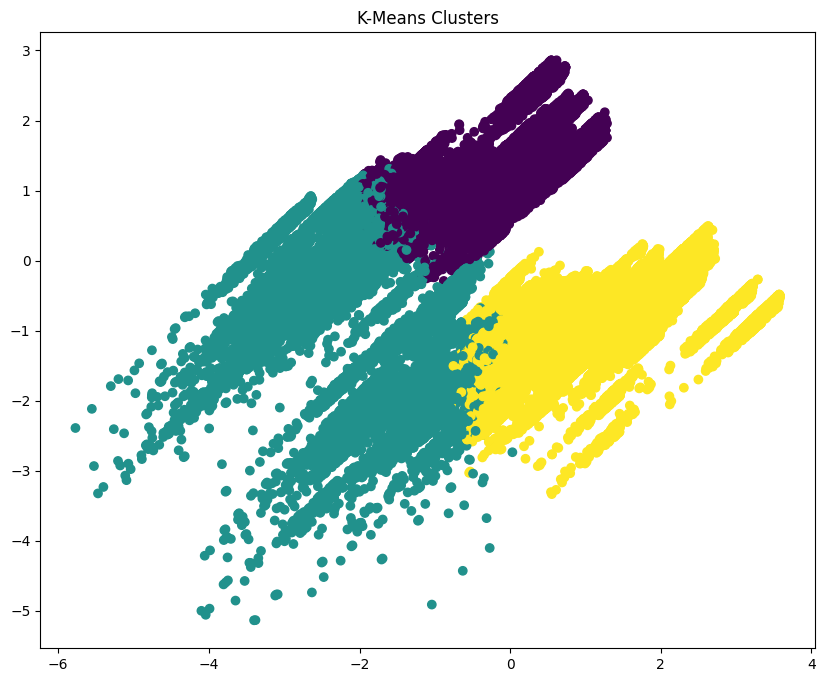

In [12]:
# Visualize clusters using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)

plt.figure(figsize=(10,8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=df["Cluster"], cmap="viridis")
plt.title("K-Means Clusters")
plt.show()

DBSCAN Clustering Evaluation Metrics
--------------------------------------
Silhouette Score       : -0.0467
Davies-Bouldin Index   : 1.3089
Number of Clusters     : 70
Noise Points Detected  : 961


/var/folders/wx/4rg4nk210z1b7k5t2v6q8gj40000gp/T/ipykernel_93981/805655119.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='DBSCAN_Cluster', data=df, palette='viridis')


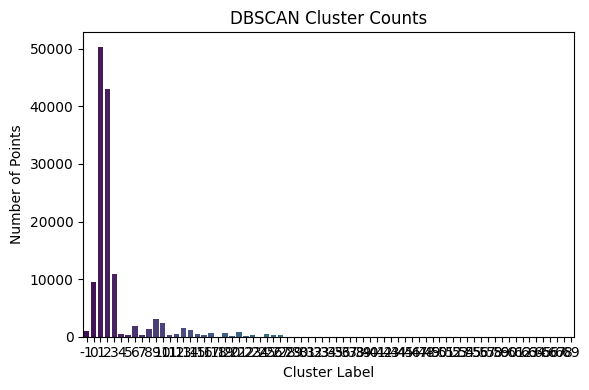

In [18]:

# -------------------------------
# Apply DBSCAN Clustering
# -------------------------------
dbscan = DBSCAN(eps=1.5, min_samples=5)
cluster_labels = dbscan.fit_predict(df_scaled)

# Add cluster labels to DataFrame
df['DBSCAN_Cluster'] = cluster_labels

# Filter out noise points (-1) for evaluation metrics
mask = cluster_labels != -1
filtered_data = df_scaled[mask]
filtered_labels = cluster_labels[mask]

# -------------------------------
# Evaluation Metrics
# -------------------------------
if len(set(filtered_labels)) > 1:
    sil_score = silhouette_score(filtered_data, filtered_labels)
    db_index = davies_bouldin_score(filtered_data, filtered_labels)
else:
    sil_score = np.nan
    db_index = np.nan

# -------------------------------
# Display Evaluation Results
# -------------------------------
print("DBSCAN Clustering Evaluation Metrics")
print("--------------------------------------")
print(f"Silhouette Score       : {sil_score:.4f}")
print(f"Davies-Bouldin Index   : {db_index:.4f}")
print(f"Number of Clusters     : {len(set(filtered_labels))}")
print(f"Noise Points Detected  : {list(cluster_labels).count(-1)}")

# -------------------------------
# Visualizations
# -------------------------------
# Bar plot of cluster counts
plt.figure(figsize=(6, 4))
sns.countplot(x='DBSCAN_Cluster', data=df, palette='viridis')
plt.title("DBSCAN Cluster Counts")
plt.xlabel("Cluster Label")
plt.ylabel("Number of Points")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Agglomerative Clustering Evaluation Metrics
Silhouette Score       : 0.4599
Davies-Bouldin Index   : 0.7280
Number of Clusters     : 3


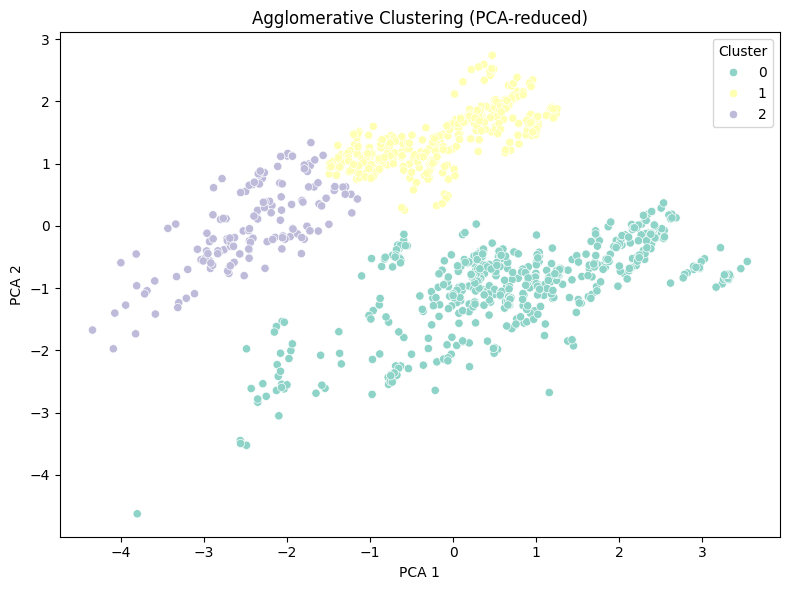

In [22]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Reduce data with PCA
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(df_scaled)

# Sample for memory safety
sample_idx = np.random.choice(len(reduced_data), 1000, replace=False)
sample_data = reduced_data[sample_idx]

# Apply Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=3)
cluster_labels = agglo.fit_predict(sample_data)

# Evaluation
sil_score = silhouette_score(sample_data, cluster_labels)
db_index = davies_bouldin_score(sample_data, cluster_labels)

# Display Results
print("Agglomerative Clustering Evaluation Metrics")
print(f"Silhouette Score       : {sil_score:.4f}")
print(f"Davies-Bouldin Index   : {db_index:.4f}")
print(f"Number of Clusters     : {len(set(cluster_labels))}")

# Visualize
plt.figure(figsize=(8, 6))
sns.scatterplot(x=sample_data[:, 0], y=sample_data[:, 1], hue=cluster_labels, palette='Set3')
plt.title("Agglomerative Clustering (PCA-reduced)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()
plt.close()


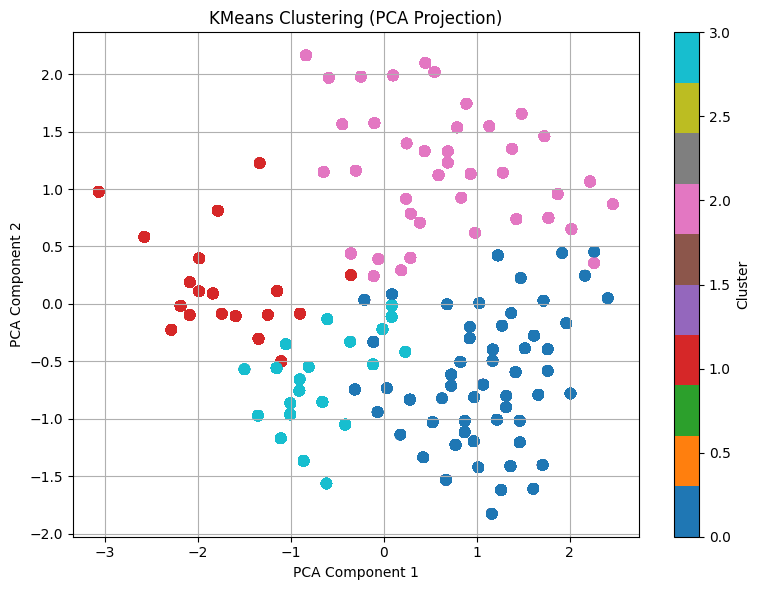

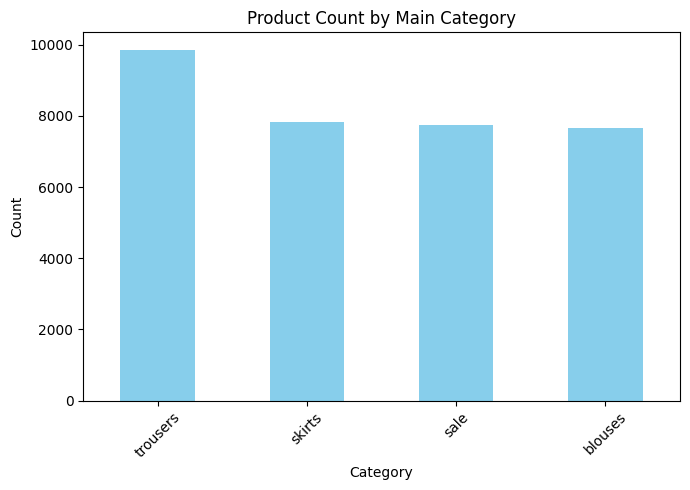

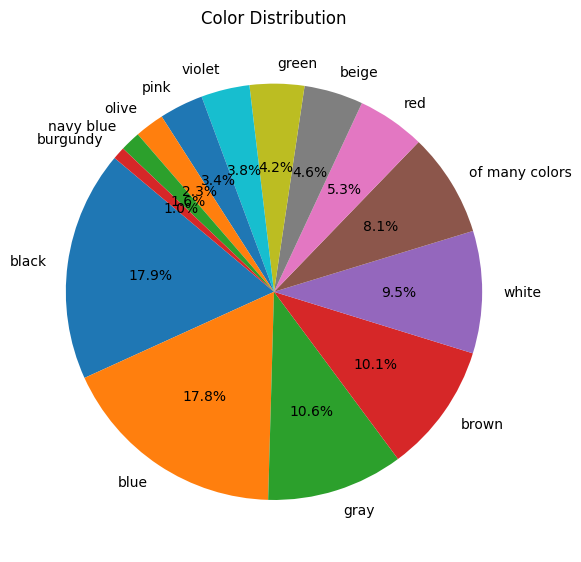

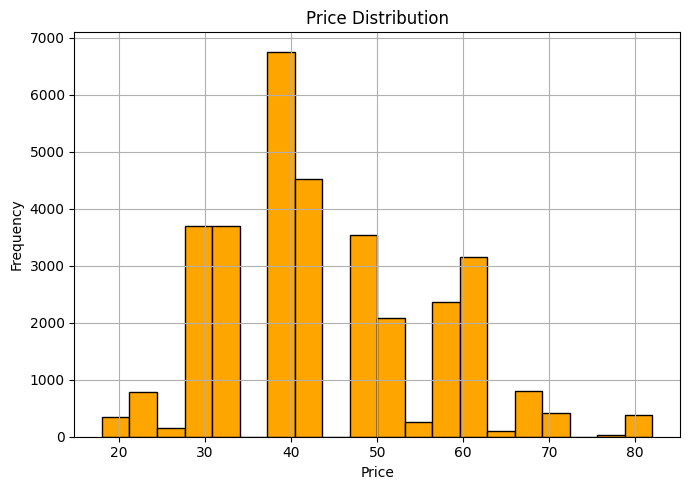


Products similar to 'C20':
     page2_clothing_model  colour  price page1_main_category
4876                   C7  violet     48             blouses
3110                  C55  violet     48             blouses


In [30]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------
# Load pre-trained models
# ------------------------------------------
with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

with open("pca.pkl", "rb") as f:
    pca = pickle.load(f)

with open("kmeans.pkl", "rb") as f:
    kmeans = pickle.load(f)

# ------------------------------------------
# Define mappings
# ------------------------------------------
main_category_mapping = {
    1: "trousers", 2: "skirts", 3: "blouses", 4: "sale"
}

colour_mapping = {
    1: "beige", 2: "black", 3: "blue", 4: "brown", 5: "burgundy", 6: "gray",
    7: "green", 8: "navy blue", 9: "of many colors", 10: "olive",
    11: "pink", 12: "red", 13: "violet", 14: "white"
}

numerical_features = ['page1_main_category', 'colour', 'price']

# ------------------------------------------
# Recommendation function
# ------------------------------------------
def recommend_products(product_name, df, num_recommendations=5):
    if product_name not in df["page2_clothing_model"].values:
        print(f"Product '{product_name}' not found in dataset.")
        return None

    product_cluster = df[df["page2_clothing_model"] == product_name]["Cluster"].values[0]
    same_cluster_df = df[df["Cluster"] == product_cluster].reset_index(drop=True)

    try:
        product_index = same_cluster_df[same_cluster_df["page2_clothing_model"] == product_name].index[0]
    except IndexError:
        print("Product not found in clustered data.")
        return None

    cluster_features = same_cluster_df[numerical_features]
    similarity = cosine_similarity(cluster_features, cluster_features)

    similar_indices = np.argsort(similarity[product_index])[::-1]
    similar_indices = [i for i in similar_indices if i != product_index][:num_recommendations]

    recommendations = same_cluster_df.iloc[similar_indices].copy()
    recommendations = recommendations.drop_duplicates(subset=["page2_clothing_model"])

    recommendations["page1_main_category"] = recommendations["page1_main_category"].map(main_category_mapping)
    recommendations["colour"] = recommendations["colour"].map(colour_mapping)

    return recommendations[["page2_clothing_model", "colour", "price", "page1_main_category"]]

# ------------------------------------------
# Main Function
# ------------------------------------------
def main(csv_file_path, input_product):
    # Load and clean data
    df = pd.read_csv(csv_file_path)
    df = df.dropna(subset=numerical_features + ["page2_clothing_model"])

    # Apply scaler, PCA, KMeans
    scaled_data = scaler.transform(df[numerical_features])
    df["Cluster"] = kmeans.predict(scaled_data)

    # Project into 2D space using PCA
    pca_features = pca.transform(scaled_data)
    df["PCA1"] = pca_features[:, 0]
    df["PCA2"] = pca_features[:, 1]

    # ------------------------------------------
    # 🎯 Visualization 1: PCA Scatter Plot
    # ------------------------------------------
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(df["PCA1"], df["PCA2"], c=df["Cluster"], cmap="tab10", s=50)
    plt.title("KMeans Clustering (PCA Projection)")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.grid(True)
    plt.colorbar(scatter, label="Cluster")
    plt.tight_layout()
    plt.show()

    # ------------------------------------------
    # 📊 Visualization 2: Bar Chart of Categories
    # ------------------------------------------
    df["page1_main_category_mapped"] = df["page1_main_category"].map(main_category_mapping)
    category_counts = df["page1_main_category_mapped"].value_counts()

    plt.figure(figsize=(7, 5))
    category_counts.plot(kind="bar", color="skyblue")
    plt.title("Product Count by Main Category")
    plt.xlabel("Category")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # ------------------------------------------
    # 🟣 Visualization 3: Pie Chart of Colours
    # ------------------------------------------
    df["colour_mapped"] = df["colour"].map(colour_mapping)
    colour_counts = df["colour_mapped"].value_counts()

    plt.figure(figsize=(6, 6))
    plt.pie(colour_counts, labels=colour_counts.index, autopct="%1.1f%%", startangle=140)
    plt.title("Color Distribution")
    plt.tight_layout()
    plt.show()

    # ------------------------------------------
    # 📉 Visualization 4: Histogram of Prices
    # ------------------------------------------
    plt.figure(figsize=(7, 5))
    plt.hist(df["price"], bins=20, color="orange", edgecolor="black")
    plt.title("Price Distribution")
    plt.xlabel("Price")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Recommendation
    recommendations = recommend_products(input_product, df, num_recommendations=5)

    if recommendations is not None:
        print(f"\nProducts similar to '{input_product}':")
        print(recommendations)
        recommendations.to_csv("real_time_recommendations.csv", index=False)
    else:
        print("No recommendations available.")

# ------------------------------------------
# Run
# ------------------------------------------
if __name__ == "__main__":
    csv_file_path = "/Users/somesh-19583/Desktop/Customer conversion/Source data/test_data.csv"
    input_product = "C20"
    main(csv_file_path, input_product)


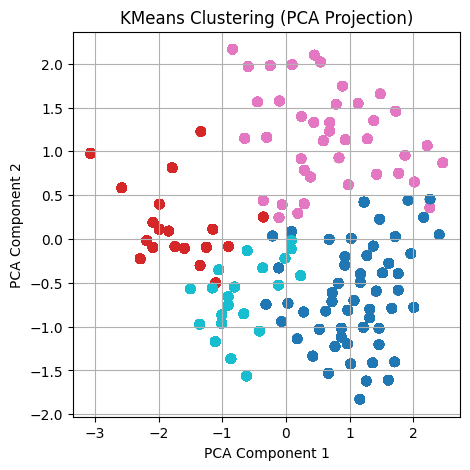

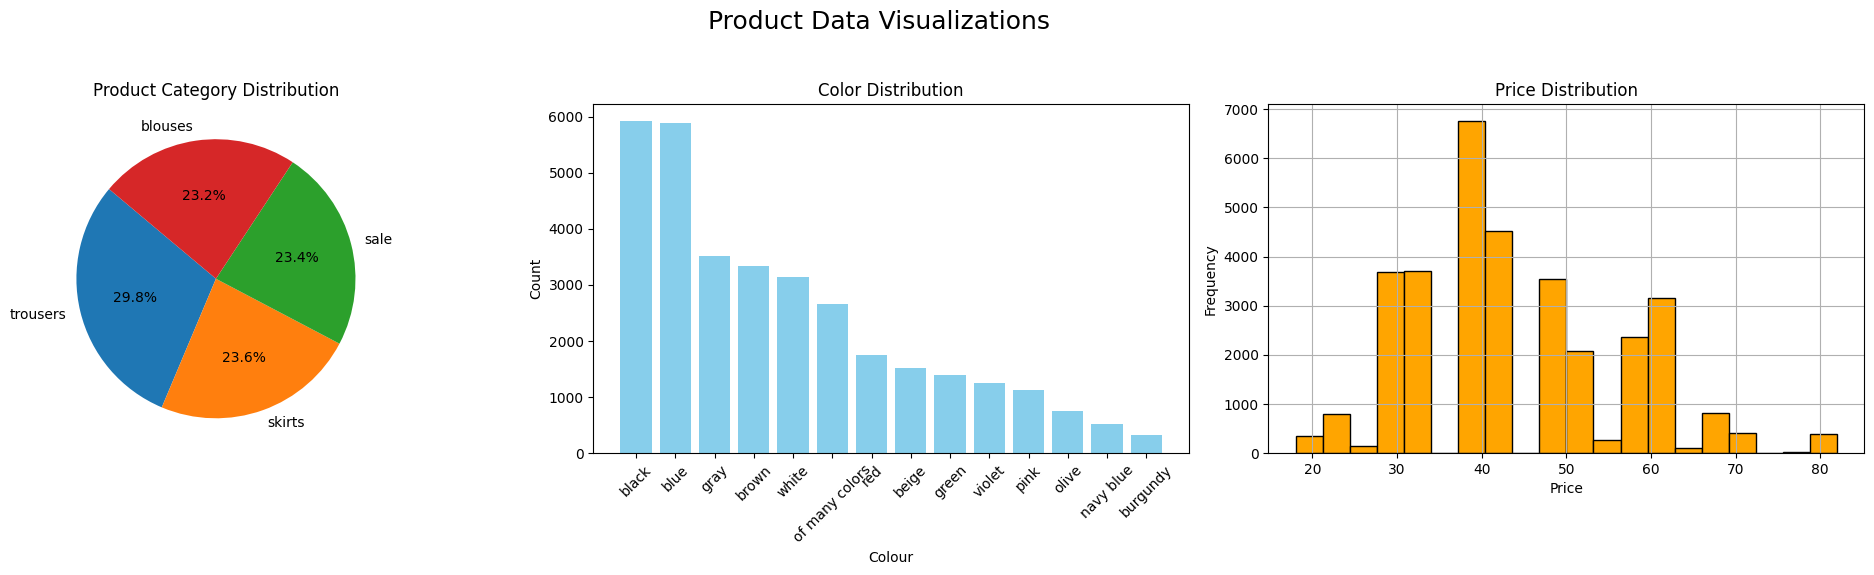

Charts pickled as 'chart_data.pkl'

Products similar to 'C20':
     page2_clothing_model  colour  price page1_main_category
4876                   C7  violet     48             blouses
3110                  C55  violet     48             blouses


In [ ]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------
# Load pre-trained models
# ------------------------------------------
with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

with open("pca.pkl", "rb") as f:
    pca = pickle.load(f)

with open("kmeans.pkl", "rb") as f:
    kmeans = pickle.load(f)

# ------------------------------------------
# Define mappings
# ------------------------------------------
main_category_mapping = {
    1: "trousers", 2: "skirts", 3: "blouses", 4: "sale"
}

colour_mapping = {
    1: "beige", 2: "black", 3: "blue", 4: "brown", 5: "burgundy", 6: "gray",
    7: "green", 8: "navy blue", 9: "of many colors", 10: "olive",
    11: "pink", 12: "red", 13: "violet", 14: "white"
}

numerical_features = ['page1_main_category', 'colour', 'price']

# ------------------------------------------
# Recommendation function
# ------------------------------------------
def recommend_products(product_name, df, num_recommendations=5):
    if product_name not in df["page2_clothing_model"].values:
        print(f"Product '{product_name}' not found in dataset.")
        return None

    product_cluster = df[df["page2_clothing_model"] == product_name]["Cluster"].values[0]
    same_cluster_df = df[df["Cluster"] == product_cluster].reset_index(drop=True)

    try:
        product_index = same_cluster_df[same_cluster_df["page2_clothing_model"] == product_name].index[0]
    except IndexError:
        print("Product not found in clustered data.")
        return None

    cluster_features = same_cluster_df[numerical_features]
    similarity = cosine_similarity(cluster_features, cluster_features)

    similar_indices = np.argsort(similarity[product_index])[::-1]
    similar_indices = [i for i in similar_indices if i != product_index][:num_recommendations]

    recommendations = same_cluster_df.iloc[similar_indices].copy()
    recommendations = recommendations.drop_duplicates(subset=["page2_clothing_model"])

    recommendations["page1_main_category"] = recommendations["page1_main_category"].map(main_category_mapping)
    recommendations["colour"] = recommendations["colour"].map(colour_mapping)

    return recommendations[["page2_clothing_model", "colour", "price", "page1_main_category"]]

# ------------------------------------------
# Main Function
# ------------------------------------------
def main(csv_file_path, input_product):
    # Load and clean data
    df = pd.read_csv(csv_file_path)
    df = df.dropna(subset=numerical_features + ["page2_clothing_model"])

    # Apply scaler, PCA, KMeans
    scaled_data = scaler.transform(df[numerical_features])
    df["Cluster"] = kmeans.predict(scaled_data)

    # Project into 2D space using PCA
    pca_features = pca.transform(scaled_data)
    df["PCA1"] = pca_features[:, 0]
    df["PCA2"] = pca_features[:, 1]

    # Map categorical values for plotting
    df["colour_mapped"] = df["colour"].map(colour_mapping)
    df["main_category_mapped"] = df["page1_main_category"].map(main_category_mapping)

    # Prepare data for charts
    category_counts = df["main_category_mapped"].value_counts()
    colour_counts = df["colour_mapped"].value_counts()

    plt.figure(figsize=(6,5))
    plt.scatter(df["PCA1"], df["PCA2"], c=df["Cluster"], cmap="tab10", s=40)
    plt.title("KMeans Clustering (PCA Projection)")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.grid(True)

    # ------------------------------------------
    # 📊 Create all plots in a single figure
    # ------------------------------------------
    fig, axs = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle("Product Data Visualizations", fontsize=18)

    # Pie chart: product category distribution
    axs[0].pie(category_counts, labels=category_counts.index, autopct="%1.1f%%", startangle=140)
    axs[0].set_title("Product Category Distribution")

    # Bar chart: color counts
    axs[1].bar(colour_counts.index, colour_counts.values, color="skyblue")
    axs[1].set_title("Color Distribution")
    axs[1].set_xlabel("Colour")
    axs[1].set_ylabel("Count")
    axs[1].tick_params(axis='x', rotation=45)

    # Histogram: price distribution
    axs[2].hist(df["price"], bins=20, color="orange", edgecolor="black")
    axs[2].set_title("Price Distribution")
    axs[2].set_xlabel("Price")
    axs[2].set_ylabel("Frequency")
    axs[2].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("combined_visualization.png")
    plt.show()

    # ------------------------------------------
    # 🎯 Pickle chart data
    # ------------------------------------------
    chart_data = {
        "bar_chart_data": colour_counts,
        "pie_chart_data": category_counts,
        "histogram_data": df["price"]
    }

    with open("chart_data.pkl", "wb") as f:
        pickle.dump(chart_data, f)
        print("Charts pickled as 'chart_data.pkl'")

    # ------------------------------------------
    # 🔁 Recommendations
    # ------------------------------------------
    recommendations = recommend_products(input_product, df, num_recommendations=5)

    if recommendations is not None:
        print(f"\nProducts similar to '{input_product}':")
        print(recommendations)
        recommendations.to_csv("real_time_recommendations.csv", index=False)
    else:
        print("No recommendations available.")

# ------------------------------------------
# Run
# ------------------------------------------
if __name__ == "__main__":
    csv_file_path = "/Users/somesh-19583/Desktop/Customer conversion/Source data/test_data.csv"
    input_product = "C20"
    main(csv_file_path, input_product)
